In [2]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [3]:
import scanpy as sc

# Load your dataset
adata_4i = sc.read_h5ad("4i/8h.h5ad")

# Basic overview
print(adata_4i)
print("Shape:", adata_4i.shape)

# View column names (metadata about each cell)
print("Observation columns:", adata_4i.obs.columns.tolist()[:10])
print("Feature columns:", adata_4i.var_names[:10].tolist())

# How many drugs (conditions)?
print("Unique conditions:", adata_4i.obs['drug'].unique())
print("Number of cells per condition:")
print(adata_4i.obs['drug'].value_counts())



AnnData object with n_obs × n_vars = 119479 × 78
    obs: 'drug'
    var: 'cell_part', 'measurement', 'stat', 'feature', 'original'
    uns: 'source'
Shape: (119479, 78)
Observation columns: ['drug']
Feature columns: ['morphology-nuclei-area', 'morphology-nuclei-circularity', 'morphology-nuclei-convexity', 'morphology-nuclei-eccentricity', 'morphology-nuclei-elongation', 'morphology-nuclei-equivalent_diameter', 'morphology-nuclei-extent', 'morphology-nuclei-major_axis_length', 'morphology-nuclei-mean_radius', 'morphology-nuclei-perimeter']
Unique conditions: ['ixazomib', 'everolimus', 'olaparib', 'paclitaxel', 'vemurafenib_cobimetinib', ..., 'ixazomib_lenalidomide_dexamethasone', 'melphalan', 'ulixertinib', 'dasatinib', 'sec.abcl']
Length: 38
Categories (38, object): ['cisplatin', 'cisplatin_olaparib', 'cl', 'control', ..., 'trametinib_panobinostat', 'ulixertinib', 'vemurafenib_cobimetinib', 'vindesine']
Number of cells per condition:
cl                                        18332
con

In [4]:
features_4i = [
    "intensity-cell-CD45-mean",
    "intensity-cell-ClCasp3-mean",
    "intensity-cell-DAPI-sum",
    "intensity-cell-Ki67-mean",
    "intensity-cell-MelA-mean",
    "intensity-cell-PCNA-mean",
    "intensity-cell-Sox9-mean",
    "intensity-cell-aTUB-mean",
    "intensity-cell-pAKT-mean",
    "intensity-cell-pEGFR-mean",
    "intensity-cell-pERK-mean",
    "intensity-cell-pMET-mean",
    "intensity-cell-pS6k1-mean",
    "intensity-nuclei-CD45-mean",
    "intensity-nuclei-ClCasp3-mean",
    "intensity-nuclei-DAPI-sum",
    "intensity-nuclei-Ki67-mean",
    "intensity-nuclei-MelA-mean",
    "intensity-nuclei-PCNA-mean",
    "intensity-nuclei-Sox9-mean",
    "intensity-nuclei-aTUB-mean",
    "intensity-nuclei-pAKT-mean",
    "intensity-nuclei-pEGFR-mean",
    "intensity-nuclei-pERK-mean",
    "intensity-nuclei-pMET-mean",
    "intensity-nuclei-pS6k1-mean",
    "morphology-cell-area",
    "morphology-cell-circularity",
    "morphology-cell-convexity",
    "morphology-cell-eccentricity",
    "morphology-cell-elongation",
    "morphology-cell-equivalent_diameter",
    "morphology-cell-extent",
    "morphology-cell-major_axis_length",
    "morphology-cell-mean_radius",
    "morphology-cell-perimeter",
    "morphology-cell-roundness",
    "morphology-nuclei-area",
    "morphology-nuclei-circularity",
    "morphology-nuclei-convexity",
    "morphology-nuclei-eccentricity",
    "morphology-nuclei-elongation",
    "morphology-nuclei-equivalent_diameter",
    "morphology-nuclei-extent",
    "morphology-nuclei-major_axis_length",
    "morphology-nuclei-mean_radius",
    "morphology-nuclei-perimeter",
    "morphology-nuclei-roundness"
]


In [5]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [6]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [64, 64 ,64 ,64],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


X_pre cells: (10995, 48)
X_post cells: (2637, 48)
(2109, 48)
(528, 48)
(2109, 48)
(528, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda
[CellOT] epoch=0 f_loss=-15296630.0000 g_loss=20882632.0000 | train mmd=0.0158 | test_mmd=0.4391


Median heuristic gamma: 0.08064887236416649
**************** Run: 0 ****************


[CellOT] epoch=50 f_loss=-1542.2155 g_loss=5414.2031 | train mmd=0.0165 | test_mmd=0.3139
[CellOT] epoch=100 f_loss=-37.5787 g_loss=6296.6816 | train mmd=0.0511 | test_mmd=0.1313
[CellOT] epoch=150 f_loss=-5953.5742 g_loss=3477.8914 | train mmd=0.1052 | test_mmd=0.2368
[CellOT] epoch=200 f_loss=-12266.1973 g_loss=3299.9387 | train mmd=0.1913 | test_mmd=0.1871
[CellOT] epoch=250 f_loss=-6896.8164 g_loss=6152.3174 | train mmd=0.1288 | test_mmd=0.1439
[CellOT] epoch=300 f_loss=-9029.7012 g_loss=7382.4004 | train mmd=0.1113 | test_mmd=0.2301
[CellOT] epoch=350 f_loss=-5989.2388 g_loss=12161.4922 | train mmd=0.1231 | test_mmd=0.2890
[CellOT] epoch=400 f_loss=-6799.8018 g_loss=7139.0581 | train mmd=0.1710 | test_mmd=0.2085
[CellOT] epoch=450 f_loss=-26321.5605 g_loss=3562.2886 | train mmd=0.1933 | test_mmd=0.1946
[CellOT] epoch=500 f_loss=-20835.9297 g_loss=1890.6779 | train mmd=0.1719 | test_mmd=0.2081
[CellOT] epoch=550 f_loss=-3930.1343 g_loss=5710.2363 | train mmd=0.1560 | test_mmd=0.116

Run 0 metrics: {'mmd2_gamma_median': 0.03831324620423582, 'mmd2_gamma_0.5': 0.042748483534174264, 'mmd2_gamma_1.0': 0.02516965017098858, 'wasserstein_distance': 2.044060325831672, 'R2_feature_means': 0.9327408873704581}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=-11960480.0000 g_loss=15889762.0000 | train mmd=0.0158 | test_mmd=0.4391
[CellOT] epoch=50 f_loss=30.4169 g_loss=4656.9517 | train mmd=0.0162 | test_mmd=0.2386
[CellOT] epoch=100 f_loss=-926.8841 g_loss=2725.9060 | train mmd=0.0474 | test_mmd=0.1763
[CellOT] epoch=150 f_loss=-1595.2621 g_loss=4435.8945 | train mmd=0.1182 | test_mmd=0.1673
[CellOT] epoch=200 f_loss=-6452.2896 g_loss=6950.8828 | train mmd=0.1798 | test_mmd=0.1572
[CellOT] epoch=250 f_loss=-9906.1074 g_loss=23840.0625 | train mmd=0.1580 | test_mmd=0.1637
[CellOT] epoch=300 f_loss=-18229.0840 g_loss=5565.4111 | train mmd=0.2052 | test_mmd=0.2147
[CellOT] epoch=350 f_loss=-20880.9102 g_loss=24124.7344 | train mmd=0.2150 | test_mmd=0.4520
[CellOT] epoch=400 f_loss=-18564.6895 g_loss=18425.3398 | train mmd=0.1420 | test_mmd=0.2405
[CellOT] epoch=450 f_loss=-4161.1577 g_loss=67353.5859 | train mmd=0.1717 | test_mmd=0.2404
[CellOT] epoch=500 f_loss=-39002.3281 g_loss=173.8842 | train mmd=0.1375 | test_mm

Run 8 metrics: {'mmd2_gamma_median': 0.031243536868514554, 'mmd2_gamma_0.5': 0.02903332764603725, 'mmd2_gamma_1.0': 0.016102493365452573, 'wasserstein_distance': 2.010409873697798, 'R2_feature_means': 0.9891119589676973}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-157.0222 g_loss=8410.3320 | train mmd=0.0162 | test_mmd=0.3757
[CellOT] epoch=100 f_loss=-2513.5271 g_loss=3957.1958 | train mmd=0.0460 | test_mmd=0.2191
[CellOT] epoch=150 f_loss=-3388.0801 g_loss=1341.0917 | train mmd=0.1025 | test_mmd=0.2044
[CellOT] epoch=200 f_loss=-7413.9907 g_loss=7183.3506 | train mmd=0.1853 | test_mmd=0.3049
[CellOT] epoch=250 f_loss=-30583.7812 g_loss=7892.9087 | train mmd=0.1425 | test_mmd=0.1826
[CellOT] epoch=300 f_loss=-12815.6016 g_loss=46532.9844 | train mmd=0.1254 | test_mmd=0.1888
[CellOT] epoch=350 f_loss=-20442.1680 g_loss=85837.1250 | train mmd=0.2075 | test_mmd=0.2262
[CellOT] epoch=400 f_loss=-8849.0020 g_loss=59287.5625 | train mmd=0.2165 | test_mmd=0.3496
[CellOT] epoch=450 f_loss=-4319.1230 g_loss=38062.9297 | train mmd=0.2206 | test_mmd=0.2568
[CellOT] epoch=500 f_loss=-94370.7578 g_loss=29658.9395 | train mmd=0.1556 | test_mmd=0.4072
[CellOT] epoch=550 f_loss=-15579.1504 g_loss=42681.4297 | train mmd=0.1621 | test_m

Run 9 metrics: {'mmd2_gamma_median': 0.03599945374464375, 'mmd2_gamma_0.5': 0.04036284437451462, 'mmd2_gamma_1.0': 0.023031167241416274, 'wasserstein_distance': 2.0503293129390903, 'R2_feature_means': 0.9545925072549222}
                        mean     std
mmd2_gamma_median     0.0463  0.0307
mmd2_gamma_0.5        0.0473  0.0237
mmd2_gamma_1.0        0.0268  0.0131
wasserstein_distance  2.0717  0.0791
R2_feature_means      0.9131  0.1108


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


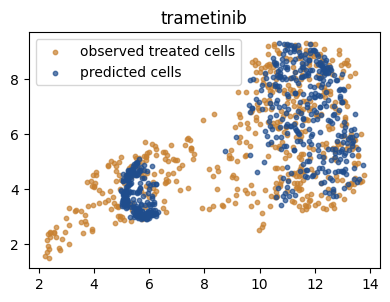

In [9]:
drug = "trametinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=10000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2631, 48)
(2104, 48)
(527, 48)
(2104, 48)
(527, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.05748945574198288
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-15357644.0000 g_loss=20191376.0000 | train mmd=0.0076 | test_mmd=0.3760
[CellOT] epoch=50 f_loss=-2524.9194 g_loss=4140.3359 | train mmd=0.0078 | test_mmd=0.2664
[CellOT] epoch=100 f_loss=-1436.7473 g_loss=2659.3604 | train mmd=0.0253 | test_mmd=0.2248
[CellOT] epoch=150 f_loss=-552.1122 g_loss=3330.6235 | train mmd=0.1220 | test_mmd=0.1598
[CellOT] epoch=200 f_loss=-15743.3525 g_loss=7093.1421 | train mmd=0.2501 | test_mmd=0.3963
[CellOT] epoch=250 f_loss=-5475.1816 g_loss=5000.7192 | train mmd=0.1697 | test_mmd=0.2502
[CellOT] epoch=300 f_loss=-39144.2031 g_loss=4348.9849 | train mmd=0.1415 | test_mmd=0.3225
[CellOT] epoch=350 f_loss=-37946.0312 g_loss=9678.1875 | train mmd=0.1348 | test_mmd=0.2780
[CellOT] epoch=400 f_loss=-21982.2773 g_loss=23078.8633 | train mmd=0.1543 | test_mmd=0.3467
[CellOT] epoch=450 f_loss=-121786.1719 g_loss=8423.6328 | train mmd=0.1326 | test_mmd=0.3273
[CellOT] epoch=500 f_loss=-16578.1328 g_loss=52040.8750 | train mmd=0.2466 | te

[CellOT] epoch=1400 f_loss=-9060.2500 g_loss=1549.7119 | train mmd=0.3504 | test_mmd=0.2446
[CellOT] epoch=1450 f_loss=937.8698 g_loss=1615.6985 | train mmd=0.3131 | test_mmd=0.2769
[CellOT] epoch=1500 f_loss=834.9850 g_loss=3701.5371 | train mmd=0.4256 | test_mmd=0.2084
[CellOT] epoch=1550 f_loss=548.5147 g_loss=1338.2703 | train mmd=0.3033 | test_mmd=0.2083
[CellOT] epoch=1600 f_loss=495.2025 g_loss=2830.0898 | train mmd=0.2904 | test_mmd=0.1591
[CellOT] epoch=1650 f_loss=158.8573 g_loss=1355.2139 | train mmd=0.2958 | test_mmd=0.1451
[CellOT] epoch=1700 f_loss=243.9730 g_loss=1182.8484 | train mmd=0.2768 | test_mmd=0.1604
[CellOT] epoch=1750 f_loss=486.1428 g_loss=1146.9314 | train mmd=0.3070 | test_mmd=0.2898
[CellOT] epoch=1800 f_loss=208.1400 g_loss=1053.0442 | train mmd=0.2220 | test_mmd=0.2065
[CellOT] epoch=1850 f_loss=199.1814 g_loss=1081.6661 | train mmd=0.3113 | test_mmd=0.1090
[CellOT] epoch=1900 f_loss=169.8398 g_loss=1037.6636 | train mmd=0.3213 | test_mmd=0.1393
[CellOT]

...

[CellOT] epoch=50 f_loss=-26.6362 g_loss=4077.6497 | train mmd=0.0079 | test_mmd=0.2102
[CellOT] epoch=100 f_loss=-663.2161 g_loss=3625.3130 | train mmd=0.0214 | test_mmd=0.2311
[CellOT] epoch=150 f_loss=-1955.1609 g_loss=3164.3459 | train mmd=0.1243 | test_mmd=0.1752
[CellOT] epoch=200 f_loss=-8980.7861 g_loss=5371.2930 | train mmd=0.1801 | test_mmd=0.1978
[CellOT] epoch=250 f_loss=-17071.5254 g_loss=5401.3628 | train mmd=0.0879 | test_mmd=0.3371
[CellOT] epoch=300 f_loss=-19789.8809 g_loss=17783.3477 | train mmd=0.3129 | test_mmd=0.1940
[CellOT] epoch=350 f_loss=-6248.9121 g_loss=18295.5547 | train mmd=0.2341 | test_mmd=0.1865
[CellOT] epoch=400 f_loss=-17781.6191 g_loss=6713.5312 | train mmd=0.1509 | test_mmd=0.2744
[CellOT] epoch=450 f_loss=-8686.4922 g_loss=14505.4619 | train mmd=0.2276 | test_mmd=0.2578
[CellOT] epoch=500 f_loss=-6237.0996 g_loss=7229.5625 | train mmd=0.2062 | test_mmd=0.1468
[CellOT] epoch=550 f_loss=-14724.4336 g_loss=3085.3726 | train mmd=0.2114 | test_mmd=0.1

Run 8 metrics: {'mmd2_gamma_median': 0.03750966173068637, 'mmd2_gamma_0.5': 0.033256301326813786, 'mmd2_gamma_1.0': 0.015823120109879595, 'wasserstein_distance': 2.3754717262493816, 'R2_feature_means': 0.9536431842204655}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-2350.7070 g_loss=3676.7148 | train mmd=0.0077 | test_mmd=0.2319
[CellOT] epoch=100 f_loss=-2325.2952 g_loss=4039.3794 | train mmd=0.0312 | test_mmd=0.1616
[CellOT] epoch=150 f_loss=-835.7825 g_loss=6607.5703 | train mmd=0.0930 | test_mmd=0.1135
[CellOT] epoch=200 f_loss=-8201.5195 g_loss=7668.3945 | train mmd=0.2153 | test_mmd=0.1502
[CellOT] epoch=250 f_loss=-9724.2578 g_loss=13547.5723 | train mmd=0.2391 | test_mmd=0.2945
[CellOT] epoch=300 f_loss=-11763.9170 g_loss=6058.1836 | train mmd=0.0899 | test_mmd=0.2762
[CellOT] epoch=350 f_loss=-88419.2344 g_loss=44942.2891 | train mmd=0.2122 | test_mmd=0.3461
[CellOT] epoch=400 f_loss=-28572.9277 g_loss=16289.0703 | train mmd=0.1859 | test_mmd=0.2211
[CellOT] epoch=450 f_loss=-2992.5718 g_loss=70315.1953 | train mmd=0.1423 | test_mmd=0.2505
[CellOT] epoch=500 f_loss=-27504.7891 g_loss=5130.9321 | train mmd=0.1699 | test_mmd=0.2078
[CellOT] epoch=550 f_loss=-29516.3906 g_loss=10214.0176 | train mmd=0.0948 | test_mm

Run 9 metrics: {'mmd2_gamma_median': 0.04586791409679969, 'mmd2_gamma_0.5': 0.040961251894641004, 'mmd2_gamma_1.0': 0.020641432191914725, 'wasserstein_distance': 2.361433500488683, 'R2_feature_means': 0.9159943911281216}
                        mean     std
mmd2_gamma_median     0.0700  0.0939
mmd2_gamma_0.5        0.0523  0.0525
mmd2_gamma_1.0        0.0247  0.0233
wasserstein_distance  2.5057  0.4003
R2_feature_means      0.7471  0.5167


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


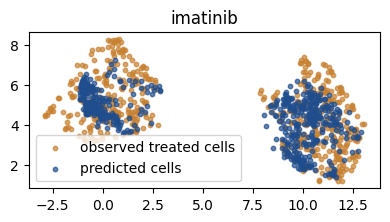

In [10]:
drug = "imatinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=10000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2693, 48)
(2154, 48)
(539, 48)
(2154, 48)
(539, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda
[CellOT] epoch=0 f_loss=-20593308.0000 g_loss=21590140.0000 | train mmd=0.0095 | test_mmd=0.3710


Median heuristic gamma: 0.07603466947967093
**************** Run: 0 ****************


[CellOT] epoch=50 f_loss=-2117.8462 g_loss=3023.8027 | train mmd=0.0101 | test_mmd=0.1968
[CellOT] epoch=100 f_loss=-452.7369 g_loss=6072.1279 | train mmd=0.0477 | test_mmd=0.1939
[CellOT] epoch=150 f_loss=-1206.7651 g_loss=3644.2188 | train mmd=0.1090 | test_mmd=0.1790


[CellOT] epoch=200 f_loss=-3913.4810 g_loss=5472.4854 | train mmd=0.1384 | test_mmd=0.1745
[CellOT] epoch=250 f_loss=-10881.7773 g_loss=6943.3711 | train mmd=0.2116 | test_mmd=0.2838
[CellOT] epoch=300 f_loss=-4129.6904 g_loss=5198.7109 | train mmd=0.1984 | test_mmd=0.2473
[CellOT] epoch=350 f_loss=-9675.9375 g_loss=24715.3555 | train mmd=0.2218 | test_mmd=0.3502
[CellOT] epoch=400 f_loss=-50574.1562 g_loss=15246.5771 | train mmd=0.1779 | test_mmd=0.1993
[CellOT] epoch=450 f_loss=-6817.8481 g_loss=31968.2266 | train mmd=0.1648 | test_mmd=0.2660
[CellOT] epoch=500 f_loss=-23399.5547 g_loss=9023.0039 | train mmd=0.1969 | test_mmd=0.2640
[CellOT] epoch=550 f_loss=-21203.2812 g_loss=10074.4971 | train mmd=0.2758 | test_mmd=0.2221
[CellOT] epoch=600 f_loss=-38344.6680 g_loss=66371.5312 | train mmd=0.2063 | test_mmd=0.2889
[CellOT] epoch=650 f_loss=-85573.4844 g_loss=13806.8076 | train mmd=0.2099 | test_mmd=0.3781
[CellOT] epoch=700 f_loss=3328.5361 g_loss=53755.7500 | train mmd=0.2224 | tes

...

[CellOT] epoch=50 f_loss=-24.9893 g_loss=5700.5513 | train mmd=0.0100 | test_mmd=0.3766
[CellOT] epoch=100 f_loss=-560.8433 g_loss=3795.5486 | train mmd=0.0437 | test_mmd=0.1745
[CellOT] epoch=150 f_loss=-1169.1134 g_loss=4356.2720 | train mmd=0.1134 | test_mmd=0.1715
[CellOT] epoch=200 f_loss=-6296.2812 g_loss=4146.3662 | train mmd=0.2118 | test_mmd=0.1710
[CellOT] epoch=250 f_loss=-6591.5063 g_loss=10339.0703 | train mmd=0.2649 | test_mmd=0.1843
[CellOT] epoch=300 f_loss=-10816.9150 g_loss=8538.1562 | train mmd=0.2743 | test_mmd=0.3473
[CellOT] epoch=350 f_loss=-9903.1582 g_loss=12458.8652 | train mmd=0.2734 | test_mmd=0.1730
[CellOT] epoch=400 f_loss=-10135.0059 g_loss=7586.2061 | train mmd=0.1559 | test_mmd=0.2182
[CellOT] epoch=450 f_loss=-8543.0859 g_loss=11963.0293 | train mmd=0.2373 | test_mmd=0.1761
[CellOT] epoch=500 f_loss=-5227.3535 g_loss=12310.6240 | train mmd=0.2131 | test_mmd=0.1494
[CellOT] epoch=550 f_loss=-21713.0664 g_loss=4973.4243 | train mmd=0.1526 | test_mmd=0.2

Run 8 metrics: {'mmd2_gamma_median': 0.05324242520323175, 'mmd2_gamma_0.5': 0.047969108132967994, 'mmd2_gamma_1.0': 0.02438789964809349, 'wasserstein_distance': 2.366853509668144, 'R2_feature_means': 0.566609046431494}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-223.7704 g_loss=5510.8594 | train mmd=0.0100 | test_mmd=0.2071
[CellOT] epoch=100 f_loss=-1872.8015 g_loss=3965.7563 | train mmd=0.0300 | test_mmd=0.2120
[CellOT] epoch=150 f_loss=-1008.2994 g_loss=4238.3828 | train mmd=0.0924 | test_mmd=0.1569
[CellOT] epoch=200 f_loss=-8376.9717 g_loss=7014.0596 | train mmd=0.2258 | test_mmd=0.1611
[CellOT] epoch=250 f_loss=-7502.3320 g_loss=9578.4404 | train mmd=0.1299 | test_mmd=0.2469
[CellOT] epoch=300 f_loss=-1742.2534 g_loss=13032.3975 | train mmd=0.1299 | test_mmd=0.2658
[CellOT] epoch=350 f_loss=-12033.7217 g_loss=2813.5659 | train mmd=0.1873 | test_mmd=0.2154
[CellOT] epoch=400 f_loss=112.8883 g_loss=12957.4092 | train mmd=0.1853 | test_mmd=0.2658
[CellOT] epoch=450 f_loss=-7553.9082 g_loss=13674.5869 | train mmd=0.2020 | test_mmd=0.2023
[CellOT] epoch=500 f_loss=-13468.3770 g_loss=6273.2720 | train mmd=0.1152 | test_mmd=0.2939
[CellOT] epoch=550 f_loss=-11475.1270 g_loss=4004.7383 | train mmd=0.1458 | test_mmd=0.18

Run 9 metrics: {'mmd2_gamma_median': 0.03742981664231115, 'mmd2_gamma_0.5': 0.03378792929506855, 'mmd2_gamma_1.0': 0.017905715867558656, 'wasserstein_distance': 2.323103052294194, 'R2_feature_means': 0.9165999861694245}
                        mean     std
mmd2_gamma_median     0.0667  0.0261
mmd2_gamma_0.5        0.0576  0.0200
mmd2_gamma_1.0        0.0305  0.0114
wasserstein_distance  2.4319  0.0952
R2_feature_means      0.4540  0.2931


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


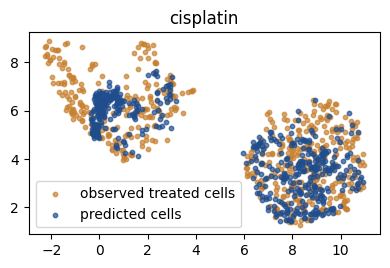

In [12]:
drug = "cisplatin"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=10000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2796, 48)
(2236, 48)
(560, 48)
(2236, 48)
(560, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda
[CellOT] epoch=0 f_loss=-17386362.0000 g_loss=17519604.0000 | train mmd=0.0089 | test_mmd=0.3776


Median heuristic gamma: 0.074449069228528
**************** Run: 0 ****************


[CellOT] epoch=50 f_loss=-2129.7295 g_loss=3293.1597 | train mmd=0.0094 | test_mmd=0.1864
[CellOT] epoch=100 f_loss=-3662.8950 g_loss=3901.2249 | train mmd=0.0316 | test_mmd=0.2768
[CellOT] epoch=150 f_loss=-6202.7637 g_loss=4549.0850 | train mmd=0.1010 | test_mmd=0.1832
[CellOT] epoch=200 f_loss=-12029.6260 g_loss=14837.2480 | train mmd=0.2326 | test_mmd=0.3406
[CellOT] epoch=250 f_loss=-11433.3027 g_loss=7017.2568 | train mmd=0.2669 | test_mmd=0.2585
[CellOT] epoch=300 f_loss=-30532.0273 g_loss=7220.0645 | train mmd=0.2188 | test_mmd=0.2167


[CellOT] epoch=350 f_loss=-2470.4780 g_loss=42038.8438 | train mmd=0.1721 | test_mmd=0.2241
[CellOT] epoch=400 f_loss=-31633.0586 g_loss=19545.6680 | train mmd=0.1275 | test_mmd=0.2702
[CellOT] epoch=450 f_loss=-25104.5469 g_loss=23422.3906 | train mmd=0.2006 | test_mmd=0.1820
[CellOT] epoch=500 f_loss=-77496.6875 g_loss=19835.8984 | train mmd=0.1593 | test_mmd=0.3571
[CellOT] epoch=550 f_loss=-30073.9297 g_loss=111876.9688 | train mmd=0.1796 | test_mmd=0.3315
[CellOT] epoch=600 f_loss=-6510.4976 g_loss=51425.0273 | train mmd=0.2160 | test_mmd=0.2879
[CellOT] epoch=650 f_loss=-22829.2734 g_loss=74250.1562 | train mmd=0.3482 | test_mmd=0.1990
[CellOT] epoch=700 f_loss=-96650.4922 g_loss=4380.5991 | train mmd=0.3147 | test_mmd=0.3716
[CellOT] epoch=750 f_loss=-103504.0156 g_loss=11829.8418 | train mmd=0.1885 | test_mmd=0.2572
[CellOT] epoch=800 f_loss=-33873.0000 g_loss=15960.9414 | train mmd=0.2073 | test_mmd=0.2224
[CellOT] epoch=850 f_loss=-34232.3906 g_loss=9058.9941 | train mmd=0.25

...

[CellOT] epoch=50 f_loss=272.5877 g_loss=3678.7075 | train mmd=0.0091 | test_mmd=0.2047
[CellOT] epoch=100 f_loss=-195.5363 g_loss=4436.8867 | train mmd=0.0456 | test_mmd=0.1675
[CellOT] epoch=150 f_loss=-2088.7336 g_loss=4081.8376 | train mmd=0.1163 | test_mmd=0.1641
[CellOT] epoch=200 f_loss=-2683.5149 g_loss=3448.2197 | train mmd=0.1534 | test_mmd=0.2194
[CellOT] epoch=250 f_loss=-4998.3208 g_loss=14725.4688 | train mmd=0.3048 | test_mmd=0.3219
[CellOT] epoch=300 f_loss=-13221.1250 g_loss=9697.2031 | train mmd=0.1794 | test_mmd=0.2508
[CellOT] epoch=350 f_loss=-24847.4141 g_loss=3358.6321 | train mmd=0.1687 | test_mmd=0.3866
[CellOT] epoch=400 f_loss=-8951.6465 g_loss=8768.8643 | train mmd=0.2173 | test_mmd=0.1996
[CellOT] epoch=450 f_loss=-19606.7578 g_loss=6802.6182 | train mmd=0.1863 | test_mmd=0.2170
[CellOT] epoch=500 f_loss=-1116.6123 g_loss=18657.6953 | train mmd=0.1799 | test_mmd=0.2752
[CellOT] epoch=550 f_loss=-5720.7070 g_loss=33104.8828 | train mmd=0.1476 | test_mmd=0.24

Run 8 metrics: {'mmd2_gamma_median': 0.07560868743096916, 'mmd2_gamma_0.5': 0.06469652912362715, 'mmd2_gamma_1.0': 0.03204745000409856, 'wasserstein_distance': 2.5499879494994784, 'R2_feature_means': 0.6975104201438664}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-178.7264 g_loss=6423.8037 | train mmd=0.0096 | test_mmd=0.2252
[CellOT] epoch=100 f_loss=-5125.6440 g_loss=6321.8145 | train mmd=0.0338 | test_mmd=0.2520
[CellOT] epoch=150 f_loss=-472.5548 g_loss=4027.2896 | train mmd=0.0630 | test_mmd=0.1838
[CellOT] epoch=200 f_loss=-20314.5996 g_loss=8311.8965 | train mmd=0.2145 | test_mmd=0.2586
[CellOT] epoch=250 f_loss=-13222.6807 g_loss=8038.5576 | train mmd=0.1508 | test_mmd=0.1911
[CellOT] epoch=300 f_loss=-26705.2812 g_loss=7623.5410 | train mmd=0.1432 | test_mmd=0.2040
[CellOT] epoch=350 f_loss=-9481.4551 g_loss=16635.8008 | train mmd=0.1318 | test_mmd=0.2306
[CellOT] epoch=400 f_loss=-8500.9824 g_loss=23849.2617 | train mmd=0.1898 | test_mmd=0.3465
[CellOT] epoch=450 f_loss=-6488.4414 g_loss=10507.8145 | train mmd=0.0983 | test_mmd=0.2851
[CellOT] epoch=500 f_loss=-7349.3965 g_loss=12891.7471 | train mmd=0.1394 | test_mmd=0.2825
[CellOT] epoch=550 f_loss=-17019.9492 g_loss=3209.7490 | train mmd=0.0938 | test_mmd=0

Run 9 metrics: {'mmd2_gamma_median': 0.06353614553727116, 'mmd2_gamma_0.5': 0.06355882750043126, 'mmd2_gamma_1.0': 0.032574669362162786, 'wasserstein_distance': 2.49191084289467, 'R2_feature_means': 0.8102223402381724}
                        mean     std
mmd2_gamma_median     0.0685  0.0119
mmd2_gamma_0.5        0.0608  0.0114
mmd2_gamma_1.0        0.0301  0.0062
wasserstein_distance  2.4936  0.0491
R2_feature_means      0.7098  0.1388


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


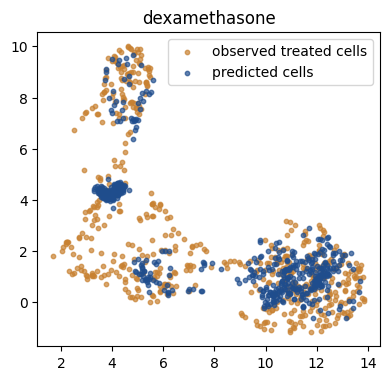

In [11]:
drug = "dexamethasone"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=10000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2858, 48)
(2286, 48)
(572, 48)
(2286, 48)
(572, 48)
**************** Run: 0 ****************
Epoch 0 | Train Loss 61771.8711 | Train MMD 0.1373 | Test MMD 0.1416 
Epoch 500 | Train Loss 31865.3613 | Train MMD 0.0260 | Test MMD 0.0318 
Epoch 1000 | Train Loss 29836.7910 | Train MMD 0.0157 | Test MMD 0.0198 
Epoch 1500 | Train Loss 29037.5371 | Train MMD 0.0135 | Test MMD 0.0162 
Epoch 2000 | Train Loss 28678.8008 | Train MMD 0.0120 | Test MMD 0.0147 
Epoch 2500 | Train Loss 28478.0098 | Train MMD 0.0115 | Test MMD 0.0139 
Epoch 3000 | Train Loss 28354.4375 | Train MMD 0.0116 | Test MMD 0.0136 
Epoch 3500 | Train Loss 28273.1738 | Train MMD 0.0113 | Test MMD 0.0135 
Epoch 4000 | Train Loss 28235.6855 | Train MMD 0.0117 | Test MMD 0.0135 
Epoch 4500 | Train Loss 28193.5352 | Train MMD 0.0112 | Test MMD 0.0134 
Epoch 5000 | Train Loss 28181.3398 | Train MMD 0.0110 | Test MMD 0.0134 
Test MMD: 0.0134
Test Wasserstein: 1.1509
                          

/Users/alireza/miniconda3/envs/pytorch_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


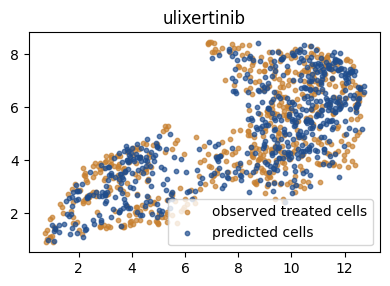

In [ ]:
drug = "ulixertinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out, history = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, layers=[32, 32 ,32], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)